<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
filename=files.upload()

Saving large_weather_prediction_dataset.csv to large_weather_prediction_dataset.csv


In [3]:
import io
filename1=next(iter(filename))
df=pd.read_csv(io.StringIO(filename[filename1].decode('utf-8')))
df.head()

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover,weather
0,23.59,35.68,15.69,1018.76,5.16,65.02,Sunny
1,26.81,43.59,14.02,1018.01,9.64,36.48,Cloudy
2,26.58,7.11,20.04,1004.03,2.20,20.91,Sunny
3,52.01,82.53,5.17,997.28,13.12,67.27,Rainy
4,18.30,47.23,10.39,1035.68,13.96,34.13,Cloudy


In [4]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['weather']=le.fit_transform(df['weather'])
df

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover,weather
0,23.59,35.68,15.69,1018.76,5.16,65.02,2
1,26.81,43.59,14.02,1018.01,9.64,36.48,0
2,26.58,7.11,20.04,1004.03,2.20,20.91,2
3,52.01,82.53,5.17,997.28,13.12,67.27,1
4,18.30,47.23,10.39,1035.68,13.96,34.13,0
...,...,...,...,...,...,...,...
149995,25.81,42.47,4.34,1029.28,13.59,50.93,1
149996,25.93,68.51,17.97,1019.10,7.45,70.79,0
149997,13.15,36.06,6.31,1032.78,9.20,22.99,1
149998,21.55,81.39,10.11,1008.13,4.17,0.00,1


In [5]:
x=df.drop(['weather'], axis=1)
y=df['weather']


In [6]:
x

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover
0,23.59,35.68,15.69,1018.76,5.16,65.02
1,26.81,43.59,14.02,1018.01,9.64,36.48
2,26.58,7.11,20.04,1004.03,2.20,20.91
3,52.01,82.53,5.17,997.28,13.12,67.27
4,18.30,47.23,10.39,1035.68,13.96,34.13
...,...,...,...,...,...,...
149995,25.81,42.47,4.34,1029.28,13.59,50.93
149996,25.93,68.51,17.97,1019.10,7.45,70.79
149997,13.15,36.06,6.31,1032.78,9.20,22.99
149998,21.55,81.39,10.11,1008.13,4.17,0.00


In [7]:
y

,weather
0,2
1,0
2,2
3,1
4,0
...,...
149995,1
149996,0
149997,1
149998,1


In [8]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
q = sc.fit_transform(xtrain)
xtrain=sc.transform(xtrain)
xtest=sc.transform(xtest)

In [10]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(xtrain, ytrain)

LogisticRegression()

In [11]:
ypred=lr.predict(xtest)

In [12]:
ypred

array([0, 2, 2, ..., 1, 0, 2])

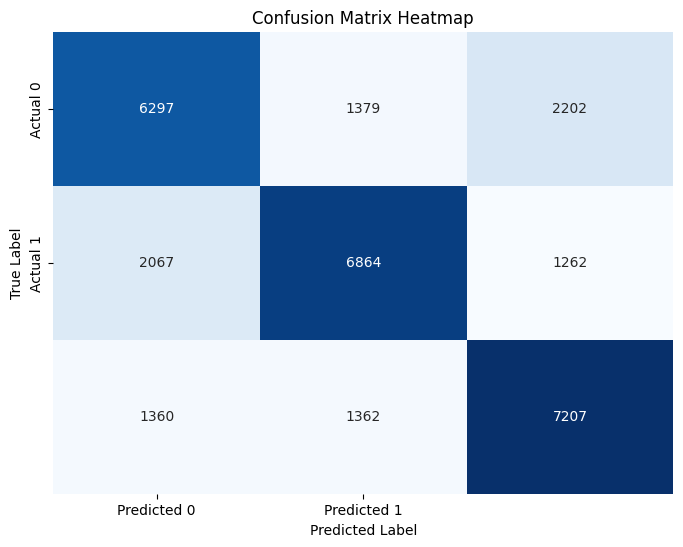

In [14]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(ytest, ypred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

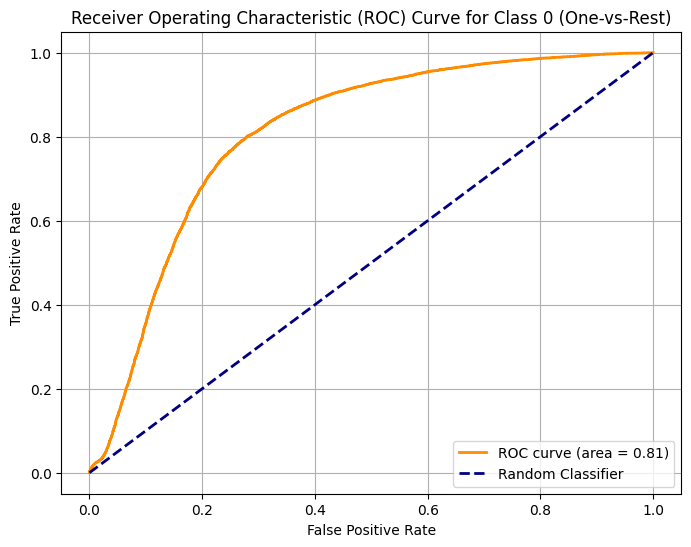

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each class from the logistic regression model
y_proba = lr.predict_proba(xtest)

# Calculate ROC curve and AUC for class 0 (one-vs-rest)
# ytest == 0 creates a binary array where True means ytest is class 0, False otherwise.
fpr, tpr, _ = roc_curve(ytest == 0, y_proba[:, 0])
roc_auc = roc_auc_score(ytest == 0, y_proba[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Class 0 (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## K-Nearest Neighbors (KNN) Classifier

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5) # You can adjust n_neighbors as needed

# Train the model
knn.fit(xtrain, ytrain)

print('KNN model trained successfully.')

KNN model trained successfully.


In [18]:
# Make predictions on the test set
ypred_knn = knn.predict(xtest)

# Get prediction probabilities for ROC curve
y_proba_knn = knn.predict_proba(xtest)

print('Predictions and probabilities generated for KNN.')

Predictions and probabilities generated for KNN.


### Evaluate KNN using Confusion Matrix

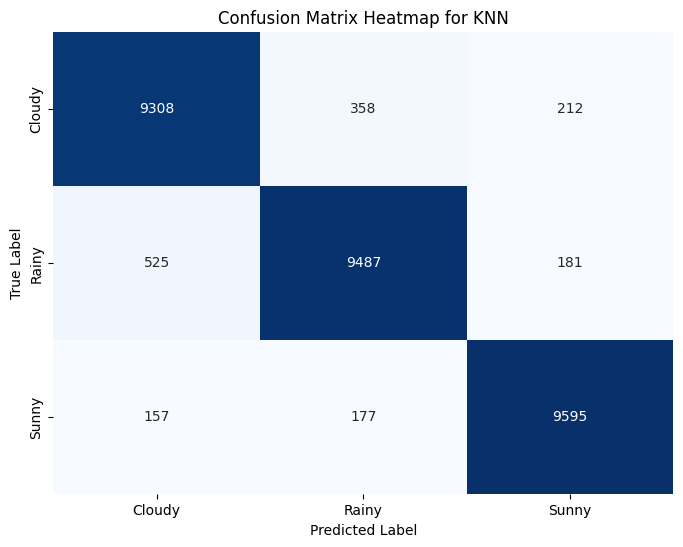

KNN Accuracy: 0.95


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Calculate confusion matrix for KNN
cm_knn = confusion_matrix(ytest, ypred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.inverse_transform(np.unique(y)),
            yticklabels=le.inverse_transform(np.unique(y)))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap for KNN')
plt.show()

# Calculate and print accuracy for KNN
accuracy_knn = accuracy_score(ytest, ypred_knn)
print(f"KNN Accuracy: {accuracy_knn:.2f}")

### Evaluate KNN using ROC Curve (One-vs-Rest for Class 0)

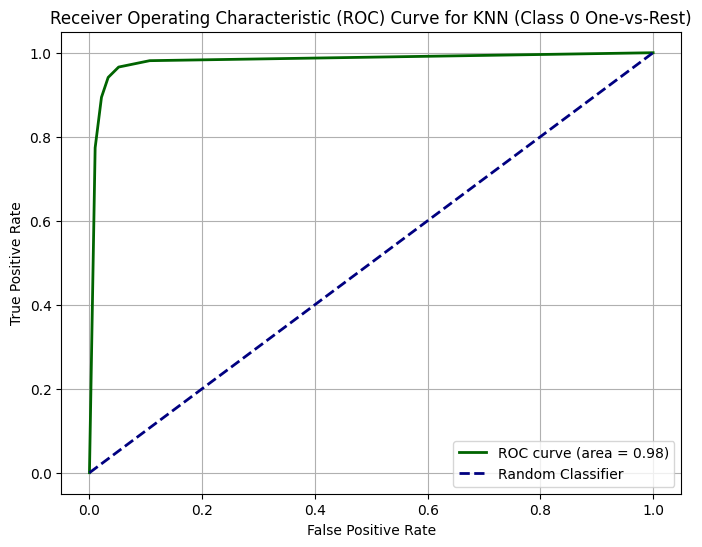

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_knn, tpr_knn, _ = roc_curve(ytest == 0, y_proba_knn[:, 0])
roc_auc_knn = roc_auc_score(ytest == 0, y_proba_knn[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN (Class 0 One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Comparing Logistic Regression and KNN ROC Curves

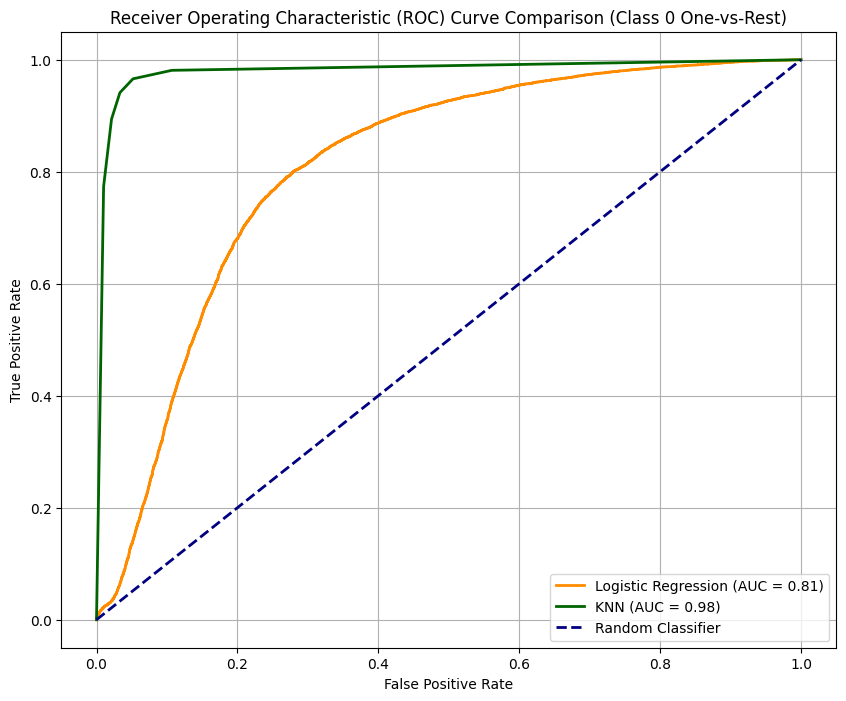

In [21]:
plt.figure(figsize=(10, 8))

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')

plt.plot(fpr_knn, tpr_knn, color='darkgreen', lw=2, label=f'KNN (AUC = {roc_auc_knn:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison (Class 0 One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()